In [ ]:
import numpy as np
import pandas as pd

ape_df = pd.DataFrame({'predicted' : [4, 2, 9],
  'actual' : [3, 5, 7]})
ape_df['error'] = ape_df['predicted'] - ape_df['actual']
ape_df.index.name = 'example'
display(ape_df)

,predicted,actual,error
example,,,
0,4,3,1
1,2,5,-3
2,9,7,2


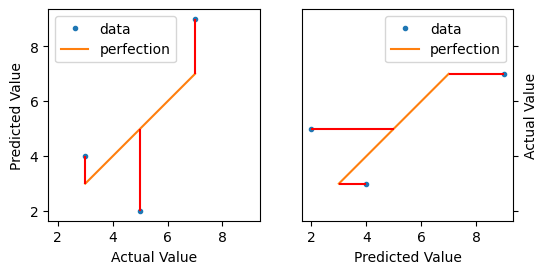

In [ ]:
import matplotlib.pyplot as plt
import itertools as it
import numpy as np
import pandas as pd

def regression_errors(figsize, predicted, actual, errors='all'):
  fig, axes = plt.subplots(1, 2, figsize=figsize,
    sharex=True, sharey=True)
  df = pd.DataFrame({'actual':actual,
    'predicted':predicted})
  for ax, (x,y) in zip(axes, it.permutations(['actual',
    'predicted'])):
    # plot the data as '.'; perfect as y=x line
    ax.plot(df[x], df[y], '.', label='data')
    ax.plot(df['actual'], df['actual'], '-',
      label='perfection')
    ax.legend()
    ax.set_xlabel('{} Value'.format(x.capitalize()))
    ax.set_ylabel('{} Value'.format(y.capitalize()))
    ax.set_aspect('equal')
  axes[1].yaxis.tick_right()
  axes[1].yaxis.set_label_position("right")
  # show connecting bars from data to perfect
  # for all or only those specified?
  if errors == 'all':
    errors = range(len(df))
  if errors:
    acts = df.actual.iloc[errors]
    preds = df.predicted.iloc[errors]
    axes[0].vlines(acts, preds, acts, 'r')
    axes[1].hlines(acts, preds, acts, 'r')
regression_errors((6, 3), ape_df.predicted, ape_df.actual)

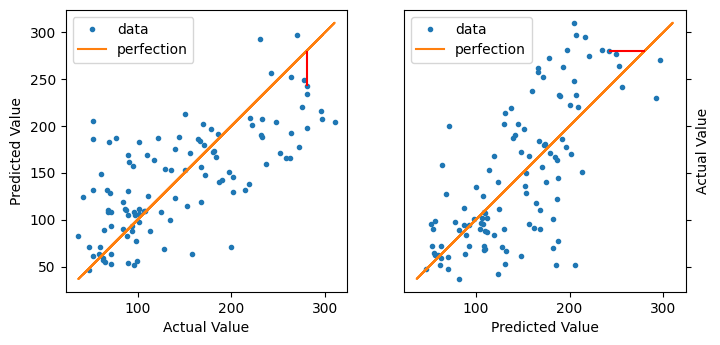

In [ ]:
from sklearn import linear_model
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
diabetes_data = diabetes.data
diabetes_target = diabetes.target

diabetes_train_ftrs, diabetes_test_ftrs, diabetes_train_tgt, diabetes_test_tgt = train_test_split(diabetes_data,
  diabetes_target, test_size=.25, random_state=42)

lr = linear_model.LinearRegression()
preds = (lr.fit(diabetes_train_ftrs, diabetes_train_tgt)
.predict(diabetes_test_ftrs))
regression_errors((8, 4), preds, diabetes_test_tgt, errors=[-20])

In [ ]:
ape_df = pd.DataFrame({'predicted' : [4, 2, 9],
  'actual' : [3, 5, 7]})
ape_df['error'] = ape_df['predicted'] - ape_df['actual']
ape_df['resid'] = ape_df['actual'] - ape_df['predicted']
ape_df.index.name = 'example'
display(ape_df)

,predicted,actual,error,resid
example,,,,
0,4,3,1,-1
1,2,5,-3,3
2,9,7,2,-2


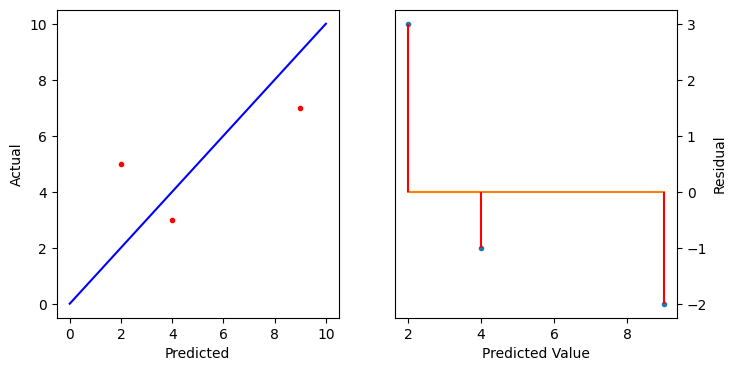

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score
from sklearn.linear_model import LinearRegression

def regression_residuals(ax, predicted, actual,
  show_errors=None, right=False):
  ''' figsize -> subplots;
    predicted/actual data -> columns of a DataFrame
    errors -> "all" or sequence of indices '''
  df = pd.DataFrame({'actual':actual,
    'predicted':predicted})
  df['error'] = df.actual - df.predicted
  ax.plot(df.predicted, df.error, '.')
  ax.plot(df.predicted, np.zeros_like(predicted), '-')
  if right:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
  ax.set_xlabel('Predicted Value')
  ax.set_ylabel('Residual')
  if show_errors == 'all':
    show_errors = range(len(df))
  if show_errors:
    preds = df.predicted.iloc[show_errors]
    errors = df.error.iloc[show_errors]
    ax.vlines(preds, 0, errors, 'r')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.plot(ape_df.predicted, ape_df.actual, 'r.', # pred vs actual
  [0, 10], [0, 10], 'b-') # perfect line
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
regression_residuals(ax2, ape_df.predicted, ape_df.actual,
  'all', right=True)

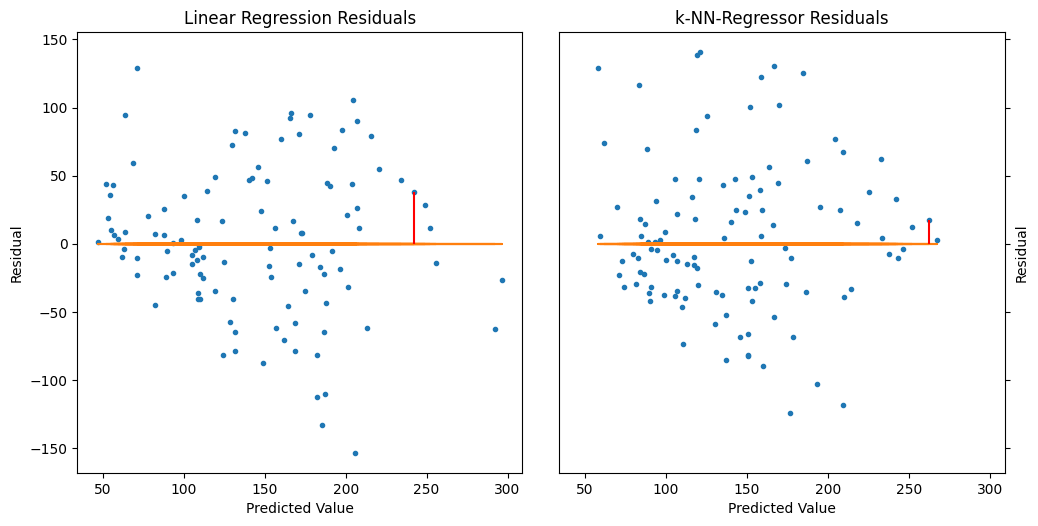

In [ ]:
from sklearn import linear_model, neighbors
import matplotlib.pyplot as plt
import numpy as np

lr = linear_model.LinearRegression()
knn = neighbors.KNeighborsRegressor()
models = [lr, knn]
fig, axes = plt.subplots(1, 2, figsize=(10, 5),
sharex=True, sharey=True)
fig.tight_layout()
for model, ax, on_right in zip(models, axes, [False, True]):
  preds = (model.fit(diabetes_train_ftrs, diabetes_train_tgt)
    .predict(diabetes_test_ftrs))
  regression_residuals(ax, preds, diabetes_test_tgt, [-20], on_right)
axes[0].set_title('Linear Regression Residuals')
axes[1].set_title('k-NN-Regressor Residuals');